<a href="https://colab.research.google.com/github/SoumitraDas1/QuantumKAN/blob/main/task9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kolmogorov–Arnold Network (KAN) with B-Splines on MNIST

This notebook implements a **classical KAN** from scratch using:
- **B-Spline basis functions** (Cox–de Boor recursion) as the learnable edge activations
- **Residual SiLU connections** per edge for training stability
- **PyTorch** for autograd + GPU support
- Applied to **MNIST** digit classification

### Architecture
```
Raw pixels [784]
    → PCA projection [64]        (no learned params; just whitening)
    → KAN Layer 1: 64 → 32      (each of 64×32 edges has a cubic B-spline, G=5)
    → KAN Layer 2: 32 → 10      (each of 32×10 edges has a cubic B-spline, G=5)
    → Softmax [10 classes]
```

### Key equations
Each edge activation is:
$$\varphi_{ij}(x) = \underbrace{\sum_{k=0}^{G+d-1} c_k \, B_k^d(x)}_{\text{B-spline}} + \underbrace{w \cdot \text{SiLU}(x)}_{\text{residual}}$$

A KAN layer computes:
$$y_j = \sum_{i} \varphi_{ij}(x_i)$$

The B-spline bases $B_k^d$ satisfy the **partition of unity** ($\sum_k B_k^d(x)=1$), which stabilises gradients.

In [ ]:
# Cell 1: Install / imports
# All packages below come pre-installed on Colab; no pip install needed.

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

from torchvision import datasets, transforms
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report

import time, math, warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## 1. B-Spline basis functions

We implement the **Cox–de Boor** recursion in vectorised PyTorch. Given:
- A clamped, uniform knot vector on $[x_{\min}, x_{\max}]$
- Spline degree $d$ (we use $d=3$, i.e. cubic)
- $G$ interior grid intervals

The number of basis functions is $n_b = G + d$.

In [ ]:
# Cell 2: B-Spline basis (vectorised Cox–de Boor)

def make_grid(grid_min: float, grid_max: float, G: int, k: int) -> torch.Tensor:
    """
    Build a clamped uniform knot vector for B-splines of degree k
    with G interior intervals on [grid_min, grid_max].

    Returns a 1-D tensor of length G + 2k + 1.
    """
    interior = torch.linspace(grid_min, grid_max, G + 1)          # G+1 knots
    step = (grid_max - grid_min) / G
    left_ext  = torch.tensor([grid_min - step * i for i in range(k, 0, -1)])
    right_ext = torch.tensor([grid_max + step * i for i in range(1, k + 1)])
    return torch.cat([left_ext, interior, right_ext])              # length G+2k+1


def bspline_basis(x: torch.Tensor, grid: torch.Tensor, k: int) -> torch.Tensor:
    """
    Evaluate all B-spline basis functions of degree k at points x.

    Args:
        x    : (N,)   input points
        grid : (M,)   knot vector (output of make_grid)
        k    : int    spline degree

    Returns:
        B    : (N, G+k)  basis evaluations  [partition of unity: rows sum to 1]
    """
    x = x.unsqueeze(1)                                             # (N, 1)
    g = grid.unsqueeze(0)                                          # (1, M)

    # Degree-0 indicator basis
    B = ((x >= g[:, :-1]) & (x < g[:, 1:])).float()               # (N, M-1)

    # Handle the rightmost point: assign it to the last interval
    B[:, -1] += (x.squeeze(1) == grid[-1]).float()

    # Cox-de Boor recursion
    for d in range(1, k + 1):
        denom_l = g[:, d:-1]   - g[:, :-(d+1)]                    # (1, M-d-1)
        denom_r = g[:, d+1:]   - g[:, 1:-d]                       # (1, M-d-1)

        # Safe division: where denominator is 0, the term contributes 0
        safe_l = torch.where(denom_l.abs() > 1e-9,
                             (x - g[:, :-(d+1)]) / denom_l.clamp(min=1e-9),
                             torch.zeros_like(denom_l))
        safe_r = torch.where(denom_r.abs() > 1e-9,
                             (g[:, d+1:] - x)    / denom_r.clamp(min=1e-9),
                             torch.zeros_like(denom_r))

        B = safe_l * B[:, :-1] + safe_r * B[:, 1:]                # (N, M-d-1)

    return B   # (N, G+k)


# ── Quick sanity-check: partition of unity ───────────────────────────────────
G_test, k_test = 5, 3
grid_test = make_grid(-1.0, 1.0, G_test, k_test)
x_test    = torch.linspace(-1, 1, 200)
B_test    = bspline_basis(x_test, grid_test, k_test)
print(f'Basis shape  : {B_test.shape}   (expected N={200}, n_basis={G_test+k_test})')
print(f'Row sum range: [{B_test.sum(1).min():.6f}, {B_test.sum(1).max():.6f}]  (should be ≈1)')
print(f'All values ≥0: {(B_test >= -1e-6).all()}')

Basis shape  : torch.Size([200, 8])   (expected N=200, n_basis=8)
Row sum range: [1.000000, 1.000000]  (should be ≈1)
All values ≥0: True


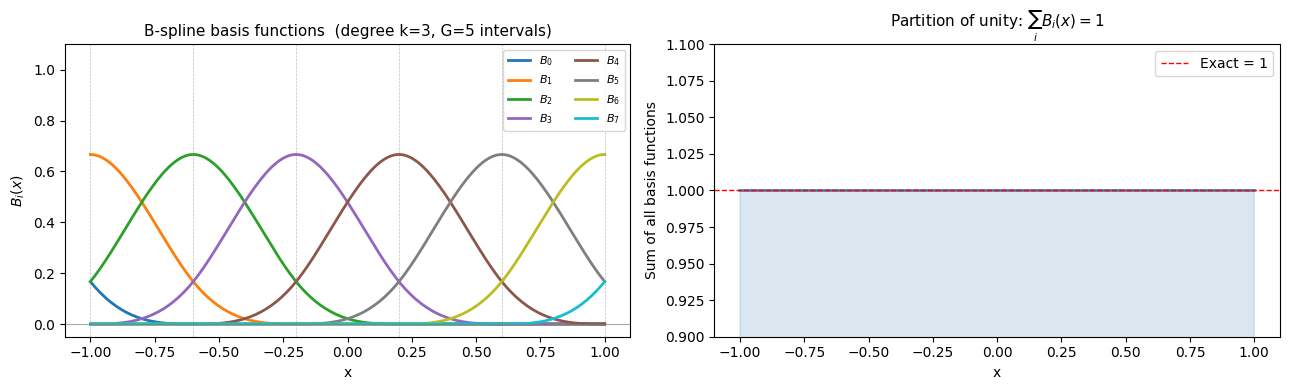

Figure saved: bspline_basis.png


In [ ]:
# Cell 3: Visualise the B-spline basis

cmap_colors = plt.cm.get_cmap('tab10', G_test + k_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: individual basis functions
ax = axes[0]
for i in range(G_test + k_test):
    ax.plot(x_test.numpy(), B_test[:, i].numpy(),
            color=cmap_colors(i), lw=2, label=f'$B_{i}$')
ax.axhline(0, color='gray', lw=0.5)
for knot in grid_test[k_test:-k_test].numpy():
    ax.axvline(knot, color='gray', lw=0.5, ls='--', alpha=0.5)
ax.set_title(f'B-spline basis functions  (degree k={k_test}, G={G_test} intervals)',
             fontsize=11)
ax.set_xlabel('x'); ax.set_ylabel('$B_i(x)$')
ax.legend(ncol=2, fontsize=8, loc='upper right')
ax.set_ylim(-0.05, 1.1)

# Right: partition of unity (should be flat =1)
ax2 = axes[1]
ax2.fill_between(x_test.numpy(), B_test.sum(1).numpy(), alpha=0.2, color='steelblue')
ax2.plot(x_test.numpy(), B_test.sum(1).numpy(), color='steelblue', lw=2)
ax2.axhline(1, color='red', lw=1, ls='--', label='Exact = 1')
ax2.set_title('Partition of unity: $\\sum_i B_i(x) = 1$', fontsize=11)
ax2.set_xlabel('x'); ax2.set_ylabel('Sum of all basis functions')
ax2.set_ylim(0.9, 1.1); ax2.legend()

plt.tight_layout()
plt.savefig('bspline_basis.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved: bspline_basis.png')

## 2. KAN Layer

A single KAN layer maps $n_{\text{in}}$ inputs to $n_{\text{out}}$ outputs. Every one of the $n_{\text{in}} \times n_{\text{out}}$ edges has:

- A B-spline with $n_b = G + k$ learnable coefficients $\mathbf{c}_{ij} \in \mathbb{R}^{n_b}$
- A scalar residual weight $w_{ij} \in \mathbb{R}$

Total parameters per layer: $n_{\text{in}} \times n_{\text{out}} \times (n_b + 1)$.

In [ ]:
# Cell 4: KANLayer

class KANLayer(nn.Module):
    """
    One KAN layer: n_in inputs → n_out outputs.

    For each of the n_in × n_out edges the activation is:
        φ_ij(x) = spline_ij(x)  +  w_ij * silu(x)

    spline_ij(x) = B(x) @ c_ij   where B(x) are the G+k B-spline basis values.
    """

    def __init__(self,
                 n_in    : int,
                 n_out   : int,
                 G       : int   = 5,
                 k       : int   = 3,
                 grid_min: float = -1.0,
                 grid_max: float =  1.0):
        super().__init__()
        self.n_in  = n_in
        self.n_out = n_out
        self.G     = G
        self.k     = k
        n_basis    = G + k                                         # number of B-spline basis fns

        # Register the knot grid as a non-trainable buffer
        grid = make_grid(grid_min, grid_max, G, k)                 # shape: (G+2k+1,)
        self.register_buffer('grid', grid)

        # Learnable spline coefficients: c[i, j, :] for edge (i→j)
        self.coef = nn.Parameter(
            torch.randn(n_in, n_out, n_basis) * 0.1
        )

        # Learnable residual (SiLU) weights
        self.w_res = nn.Parameter(
            torch.ones(n_in, n_out) * 0.1
        )

        # Layer-norm for stable training
        self.layer_norm = nn.LayerNorm(n_out)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x : (batch, n_in)  — input activations
        Returns:
            y : (batch, n_out) — output activations
        """
        batch = x.shape[0]

        # Clamp inputs to the spline's domain to avoid extrapolation artifacts
        x_clamped = x.clamp(self.grid[0].item(), self.grid[-1].item() - 1e-6)  # (B, n_in)

        # Evaluate basis for every input feature: loop over features
        # x_clamped: (B, n_in)  →  basis: (B, n_in, n_basis)
        basis_list = []
        for i in range(self.n_in):
            b = bspline_basis(x_clamped[:, i], self.grid, self.k)  # (B, n_basis)
            basis_list.append(b)
        basis = torch.stack(basis_list, dim=1)                     # (B, n_in, n_basis)

        # b = batch, i = n_in, f = n_basis (basis Functions), o = n_out (Output)
        spline_out = torch.einsum('bif,iof->bo', basis, self.coef)

        # Residual SiLU contribution
        silu_out = F.silu(x)                                       # (B, n_in)
        # Weighted sum: (B, n_in) × (n_in, n_out) → (B, n_out)
        res_out  = silu_out @ self.w_res                           # (B, n_out)

        y = spline_out + res_out
        return self.layer_norm(y)

In [ ]:
#  Cell 5: Full KAN model

class KAN(nn.Module):
    """
    Multi-layer KAN.

    sizes : list of layer widths, e.g. [64, 32, 10]
    G     : number of B-spline grid intervals
    k     : spline degree
    """

    def __init__(self, sizes, G=5, k=3, grid_min=-1.0, grid_max=1.0):
        super().__init__()
        self.layers = nn.ModuleList([
            KANLayer(sizes[i], sizes[i+1], G, k, grid_min, grid_max)
            for i in range(len(sizes) - 1)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x   # raw logits; apply softmax externally

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Instantiate and inspect
model = KAN(sizes=[64, 32, 10], G=5, k=3).to(DEVICE)
print(model)
print(f'\nTotal trainable parameters: {model.count_parameters():,}')

# Quick forward-pass test
dummy = torch.randn(8, 64).to(DEVICE)
out   = model(dummy)
print(f'Input shape: {dummy.shape}  →  Output shape: {out.shape}')

KAN(
  (layers): ModuleList(
    (0): KANLayer(
      (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    )
    (1): KANLayer(
      (layer_norm): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
    )
  )
)

Total trainable parameters: 21,396
Input shape: torch.Size([8, 64])  →  Output shape: torch.Size([8, 10])


## 3. MNIST Data Pipeline

MNIST has 28×28=784 input features. We apply **PCA** (64 components, whitened) before feeding into the KAN. This:
1. Reduces the quadratic parameter cost of KAN edges from 784×32 to 64×32
2. Decorrelates features, helping the B-spline domain $[-1, 1]$ stay relevant
3. Has no learned parameters — it's purely a preprocessing step

In [ ]:
# Cell 6: Load MNIST + PCA preprocessing

print('Loading MNIST...')
transform = transforms.Compose([transforms.ToTensor()])

train_raw = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_raw  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Flatten to numpy for PCA
X_train_np = train_raw.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_train_np = train_raw.targets.numpy()
X_test_np  = test_raw.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_test_np  = test_raw.targets.numpy()

print(f'Train: {X_train_np.shape}, Test: {X_test_np.shape}')

# Fit PCA on training set
N_COMPONENTS = 64
print(f'Fitting PCA with {N_COMPONENTS} components...')
pca = PCA(n_components=N_COMPONENTS, whiten=True, random_state=42)
X_train_pca = pca.fit_transform(X_train_np).astype(np.float32)
X_test_pca  = pca.transform(X_test_np).astype(np.float32)

print(f'Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')
print(f'PCA output range  : [{X_train_pca.min():.3f}, {X_train_pca.max():.3f}]')

# Clip to [-1, 1] to keep within spline domain
X_train_pca = np.clip(X_train_pca, -3, 3) / 3.0   # normalise to [-1, 1]
X_test_pca  = np.clip(X_test_pca,  -3, 3) / 3.0

print(f'After normalisation: [{X_train_pca.min():.3f}, {X_train_pca.max():.3f}]')

# Build PyTorch datasets
BATCH = 256

train_ds = TensorDataset(
    torch.tensor(X_train_pca), torch.tensor(y_train_np, dtype=torch.long)
)
test_ds  = TensorDataset(
    torch.tensor(X_test_pca),  torch.tensor(y_test_np,  dtype=torch.long)
)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2)

print(f'\nTrain batches: {len(train_loader)}, Test batches: {len(test_loader)}')

Loading MNIST...


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 498kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.99MB/s]


Train: (60000, 784), Test: (10000, 784)
Fitting PCA with 64 components...
Explained variance: 86.2%
PCA output range  : [-5.651, 6.018]
After normalisation: [-1.000, 1.000]

Train batches: 235, Test batches: 40


## 4. Training

In [ ]:
# Cell 7: Training loop

EPOCHS   = 20
LR       = 1e-3
WD       = 1e-4   # weight decay (L2 regularisation on spline coefficients)

model     = KAN(sizes=[64, 32, 10], G=5, k=3).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}


def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            total_loss += criterion(logits, yb).item() * len(yb)
            correct    += (logits.argmax(1) == yb).sum().item()
            total      += len(yb)
    return total_loss / total, correct / total


print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  "
      f"{'Val Loss':>8}  {'Val Acc':>7}  {'LR':>8}  {'Time':>6}")
print('─' * 72)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    running_loss, running_correct, running_n = 0.0, 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clip
        optimizer.step()

        running_loss    += loss.item() * len(yb)
        running_correct += (logits.argmax(1) == yb).sum().item()
        running_n       += len(yb)

    scheduler.step()

    tr_loss = running_loss    / running_n
    tr_acc  = running_correct / running_n
    vl_loss, vl_acc = evaluate(test_loader)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    lr_now = scheduler.get_last_lr()[0]
    print(f"{epoch:6d}  {tr_loss:10.4f}  {tr_acc*100:8.2f}%  "
          f"{vl_loss:8.4f}  {vl_acc*100:6.2f}%  {lr_now:.2e}  {time.time()-t0:5.1f}s")

print('─' * 72)
print(f'Best val accuracy: {max(history["val_acc"])*100:.2f}%  '
      f'(epoch {np.argmax(history["val_acc"])+1})')

 Epoch  Train Loss  Train Acc  Val Loss  Val Acc        LR    Time
────────────────────────────────────────────────────────────────────────
     1      1.2214     66.33%    0.5776   89.79%  9.94e-04   38.6s
     2      0.4640     91.19%    0.3660   93.05%  9.76e-04   37.3s
     3      0.3200     93.40%    0.2756   94.31%  9.46e-04   37.6s
     4      0.2468     94.68%    0.2276   95.02%  9.05e-04   38.2s
     5      0.2032     95.43%    0.1986   95.36%  8.54e-04   37.0s
     6      0.1730     96.01%    0.1831   95.41%  7.94e-04   37.8s
     7      0.1512     96.47%    0.1649   95.96%  7.27e-04   47.0s
     8      0.1331     96.89%    0.1535   96.13%  6.55e-04   39.5s
     9      0.1203     97.18%    0.1474   96.24%  5.78e-04   39.8s
    10      0.1094     97.50%    0.1442   96.28%  5.00e-04   40.0s
    11      0.1010     97.65%    0.1345   96.48%  4.22e-04   37.2s
    12      0.0936     97.89%    0.1374   96.42%  3.45e-04   37.0s
    13      0.0874     98.01%    0.1298   96.49%  2.73e-

## 5. Performance on the Test Set

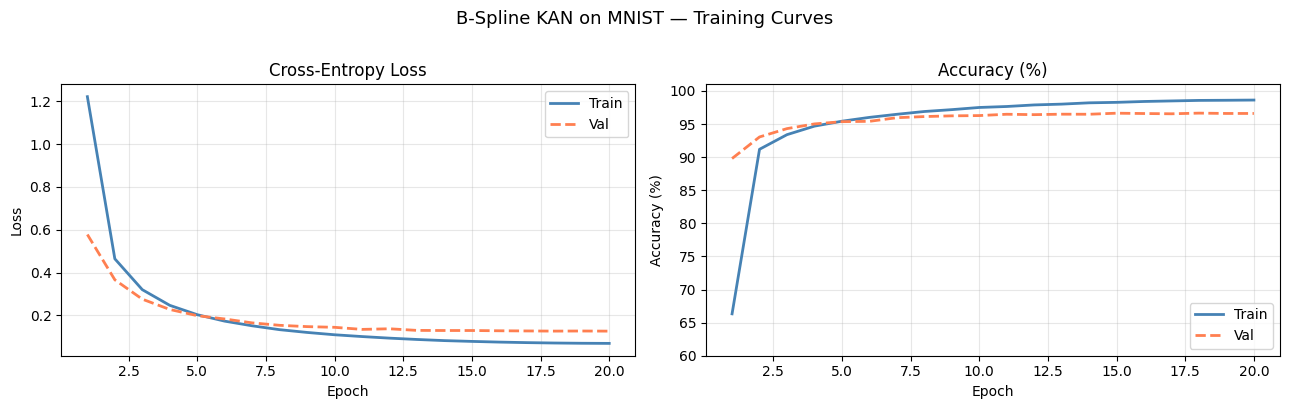

In [ ]:
#  Cell 8: Training curves

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ep = range(1, EPOCHS + 1)

axes[0].plot(ep, history['train_loss'], label='Train', color='steelblue', lw=2)
axes[0].plot(ep, history['val_loss'],   label='Val',   color='coral',     lw=2, ls='--')
axes[0].set_title('Cross-Entropy Loss', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, [a*100 for a in history['train_acc']], label='Train', color='steelblue', lw=2)
axes[1].plot(ep, [a*100 for a in history['val_acc']],   label='Val',   color='coral',     lw=2, ls='--')
axes[1].set_title('Accuracy (%)', fontsize=12)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(60, 101)

plt.suptitle('B-Spline KAN on MNIST — Training Curves', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('kan_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# Cell 9: Full test-set evaluation + classification report

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        preds  = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f'\n==============================')
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Test Errors   : {(all_preds != all_labels).sum()} / {len(all_labels)}')
print(f'==============================')
print()
print(classification_report(all_labels, all_preds,
                             target_names=[str(i) for i in range(10)]))


  Test Accuracy : 96.60%
  Test Errors   : 340 / 10000

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.96      0.96      1032
           3       0.96      0.96      0.96      1010
           4       0.96      0.96      0.96       982
           5       0.96      0.96      0.96       892
           6       0.97      0.97      0.97       958
           7       0.96      0.96      0.96      1028
           8       0.95      0.97      0.96       974
           9       0.96      0.94      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



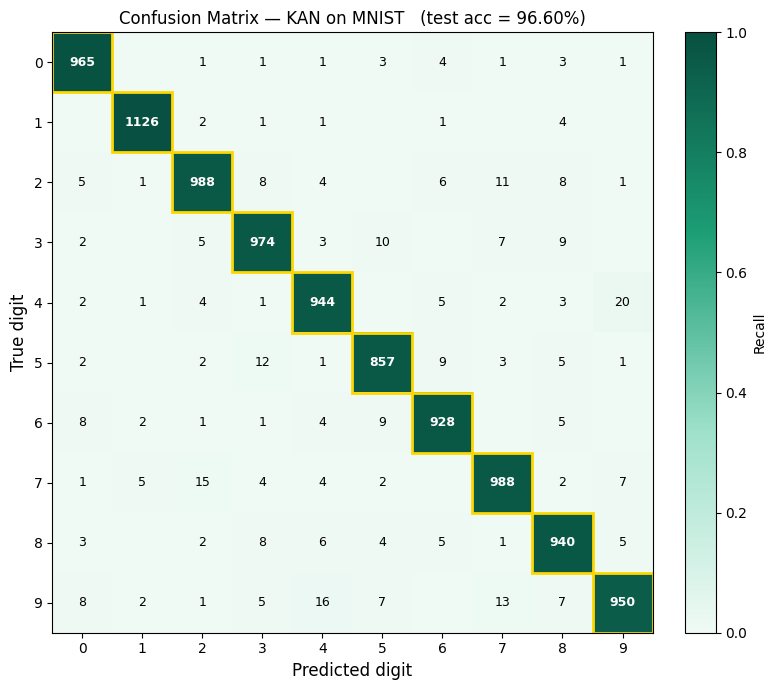

In [ ]:
# Cell 10: Confusion matrix

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(9, 7))

# Custom green colormap
cmap = LinearSegmentedColormap.from_list('kan_green',
    ['#f0faf5', '#9FE1CB', '#1D9E75', '#085041'], N=256)

# Normalise to per-true-class recall for colour scaling
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Recall')

for i in range(10):
    for j in range(10):
        val  = cm[i, j]
        if val == 0:
            continue
        col  = 'white' if cm_norm[i, j] > 0.55 else 'black'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=9, color=col, fontweight='bold' if i==j else 'normal')

ticks = range(10)
ax.set_xticks(ticks); ax.set_xticklabels(ticks)
ax.set_yticks(ticks); ax.set_yticklabels(ticks)
ax.set_xlabel('Predicted digit', fontsize=12)
ax.set_ylabel('True digit',      fontsize=12)
ax.set_title(f'Confusion Matrix — KAN on MNIST   (test acc = {test_acc*100:.2f}%)',
             fontsize=12)

# Highlight diagonal
for i in range(10):
    ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1,
                                fill=False, edgecolor='gold', lw=2))

plt.tight_layout()
plt.savefig('kan_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

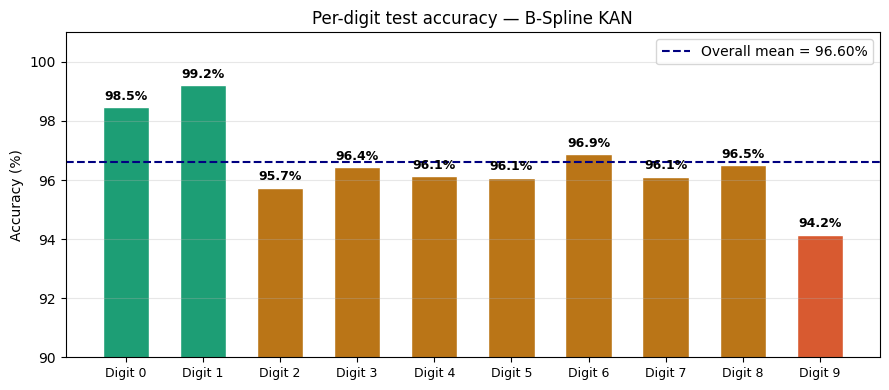

In [ ]:
# Cell 11: Per-digit accuracy bar chart

per_digit_acc = []
for d in range(10):
    mask = all_labels == d
    per_digit_acc.append((all_preds[mask] == d).mean() * 100)

fig, ax = plt.subplots(figsize=(9, 4))
colors  = ['#1D9E75' if a >= 97 else '#BA7517' if a >= 95 else '#D85A30'
           for a in per_digit_acc]

bars = ax.bar(range(10), per_digit_acc, color=colors, edgecolor='white', width=0.6)

for bar, acc in zip(bars, per_digit_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(test_acc * 100, color='navy', lw=1.5, ls='--',
           label=f'Overall mean = {test_acc*100:.2f}%')
ax.set_xticks(range(10))
ax.set_xticklabels([f'Digit {d}' for d in range(10)], fontsize=9)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(90, 101)
ax.set_title('Per-digit test accuracy — B-Spline KAN', fontsize=12)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('kan_per_digit_acc.png', dpi=120, bbox_inches='tight')
plt.show()

Total misclassified: 340 out of 10000


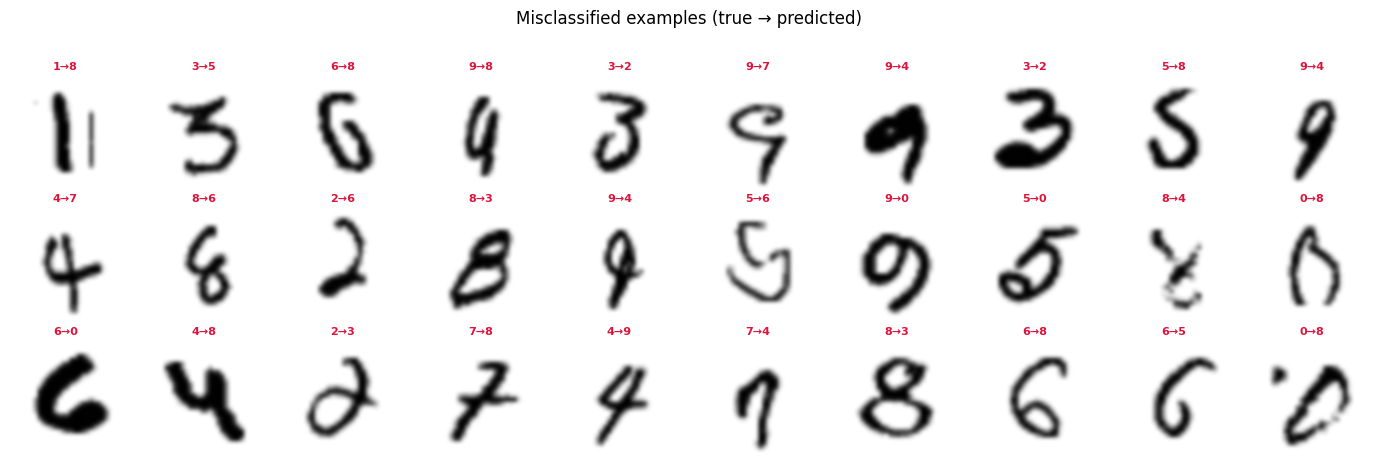

In [ ]:
# Cell 12: Visualise misclassified examples

wrong_idx = np.where(all_preds != all_labels)[0]
print(f'Total misclassified: {len(wrong_idx)} out of {len(all_labels)}')

# Show up to 30 mistakes
show_n   = min(30, len(wrong_idx))
chosen   = np.random.choice(wrong_idx, show_n, replace=False)

# Retrieve original (non-PCA) images from test set
test_images = test_raw.data.numpy()   # (10000, 28, 28)

fig, axes = plt.subplots(3, 10, figsize=(14, 4.5))
fig.suptitle('Misclassified examples (true → predicted)', fontsize=12, y=1.02)

for ax, idx in zip(axes.flat, chosen):
    ax.imshow(test_images[idx], cmap='gray_r', interpolation='bicubic')
    ax.set_title(f'{all_labels[idx]}→{all_preds[idx]}',
                 fontsize=8, color='crimson', fontweight='bold')
    ax.axis('off')

# Hide any unused axes
for ax in axes.flat[show_n:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('kan_misclassified.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Interpretability — Visualising Learned Spline Functions

A key advantage of KANs over MLPs: you can **plot the learned activation function on each edge**. Here we visualise a sample of edges from Layer 1 to see what univariate mappings the network discovered.

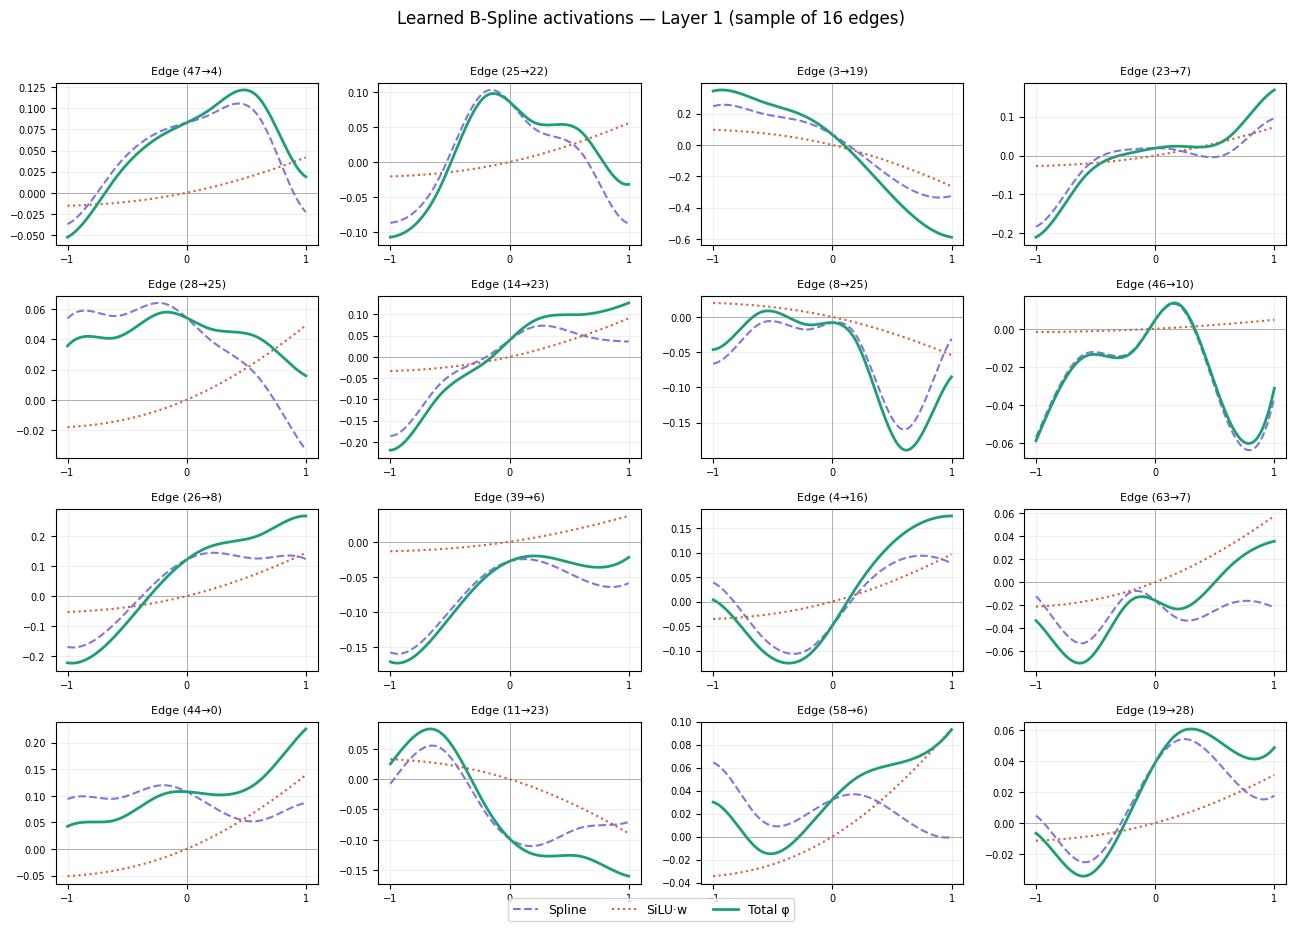

In [ ]:
#  Cell 13: Visualise learned spline functions on Layer 1 edges

model.eval()
layer0 = model.layers[0]   # first KAN layer: 64 inputs → 32 outputs

x_vis = torch.linspace(-1.0, 1.0, 300).to(DEVICE)

# Sample 16 random edges (input_feat → output_neuron)
np.random.seed(7)
sampled_edges = [(np.random.randint(0, 64), np.random.randint(0, 32))
                 for _ in range(16)]

fig, axes = plt.subplots(4, 4, figsize=(13, 9))
fig.suptitle('Learned B-Spline activations — Layer 1 (sample of 16 edges)',
             fontsize=12, y=1.01)

with torch.no_grad():
    for ax, (i, j) in zip(axes.flat, sampled_edges):
        # Evaluate spline for edge (i → j)
        B = bspline_basis(x_vis, layer0.grid, layer0.k)         # (300, n_basis)
        spline_vals = B @ layer0.coef[i, j, :]                  # (300,)
        silu_vals   = F.silu(x_vis) * layer0.w_res[i, j]        # (300,)
        total_vals  = spline_vals + silu_vals

        x_np = x_vis.cpu().numpy()
        ax.plot(x_np, spline_vals.cpu().numpy(),
                label='Spline', color='#7F77DD', lw=1.5, ls='--')
        ax.plot(x_np, silu_vals.cpu().numpy(),
                label='SiLU·w', color='#D85A30', lw=1.5, ls=':')
        ax.plot(x_np, total_vals.cpu().numpy(),
                label='Total φ', color='#1D9E75', lw=2)
        ax.axhline(0, color='gray', lw=0.4)
        ax.axvline(0, color='gray', lw=0.4)
        ax.set_title(f'Edge ({i}→{j})', fontsize=8)
        ax.set_xticks([-1, 0, 1]); ax.tick_params(labelsize=7)
        ax.grid(alpha=0.2)

# Single legend for the whole figure
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.savefig('kan_learned_splines.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Comparison: KAN vs MLP (same scale)

In [ ]:
# ── Cell 14: Baseline MLP for comparison

class MLP(nn.Module):
    def __init__(self, sizes, dropout=0.1):
        super().__init__()
        layers = []
        for i in range(len(sizes) - 1):
            layers += [nn.Linear(sizes[i], sizes[i+1])]
            if i < len(sizes) - 2:
                layers += [nn.BatchNorm1d(sizes[i+1]),
                           nn.ReLU(),
                           nn.Dropout(dropout)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def train_model(model, n_epochs=20, lr=1e-3, wd=1e-4):
    opt  = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    crit  = nn.CrossEntropyLoss()
    hist  = {'train_acc': [], 'val_acc': []}

    for epoch in range(n_epochs):
        model.train()
        correct, total = 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            correct += (model(xb).argmax(1)==yb).sum().item()
            total   += len(yb)
        sched.step()
        _, va = evaluate_generic(model, test_loader)
        hist['train_acc'].append(correct/total)
        hist['val_acc'].append(va)

    return hist


def evaluate_generic(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    crit = nn.CrossEntropyLoss()
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss_sum += crit(logits, yb).item() * len(yb)
            correct  += (logits.argmax(1)==yb).sum().item()
            total    += len(yb)
    return loss_sum/total, correct/total


print('Training MLP [64→32→10] ...')
mlp_small = MLP([64, 32, 10]).to(DEVICE)
hist_mlp  = train_model(mlp_small, n_epochs=EPOCHS)
_, mlp_acc = evaluate_generic(mlp_small, test_loader)

print('Training larger MLP [64→128→64→10] ...')
mlp_large   = MLP([64, 128, 64, 10]).to(DEVICE)
hist_mlp_lg = train_model(mlp_large, n_epochs=EPOCHS)
_, mlp_lg_acc = evaluate_generic(mlp_large, test_loader)

print(f'\n==== Final comparison ====')
print(f'  KAN [64→32→10] G=5 k=3  : {test_acc*100:.2f}%  ({model.count_parameters():,} params)')
print(f'  MLP [64→32→10]           : {mlp_acc*100:.2f}%  ({mlp_small.count_parameters():,} params)')
print(f'  MLP [64→128→64→10]       : {mlp_lg_acc*100:.2f}%  ({mlp_large.count_parameters():,} params)')

Training MLP [64→32→10] ...
Training larger MLP [64→128→64→10] ...

==== Final comparison ====
  KAN [64→32→10] G=5 k=3  : 96.60%  (21,396 params)
  MLP [64→32→10]           : 95.99%  (2,474 params)
  MLP [64→128→64→10]       : 98.17%  (17,610 params)


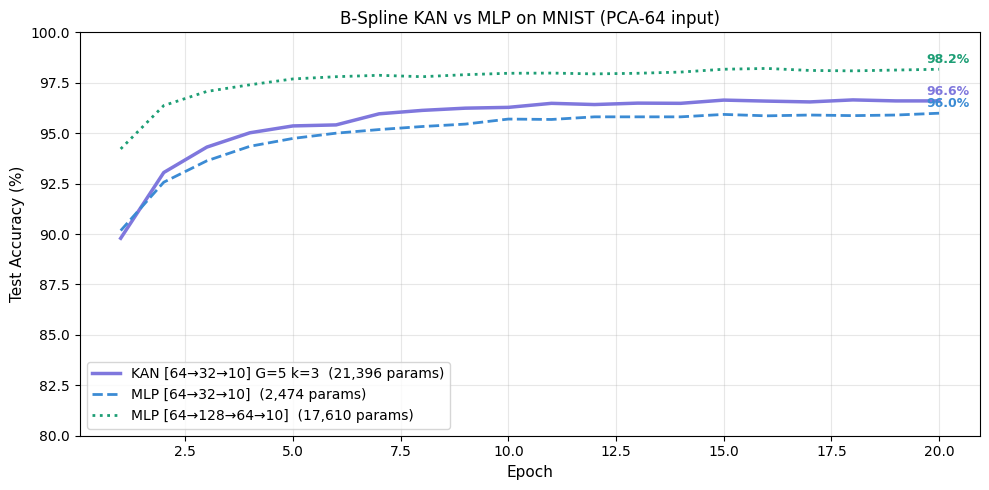

In [ ]:
# Cell 15: Comparison plot

fig, ax = plt.subplots(figsize=(10, 5))

ep = range(1, EPOCHS + 1)
ax.plot(ep, [a*100 for a in history['val_acc']],       lw=2.5, color='#7F77DD',
        label=f'KAN [64→32→10] G=5 k=3  ({model.count_parameters():,} params)')
ax.plot(ep, [a*100 for a in hist_mlp['val_acc']],      lw=2,   color='#3B8BD4',
        ls='--', label=f'MLP [64→32→10]  ({mlp_small.count_parameters():,} params)')
ax.plot(ep, [a*100 for a in hist_mlp_lg['val_acc']],   lw=2,   color='#1D9E75',
        ls=':', label=f'MLP [64→128→64→10]  ({mlp_large.count_parameters():,} params)')

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('B-Spline KAN vs MLP on MNIST (PCA-64 input)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim(80, 100)

# Annotate final accuracies
final_vals = [
    (history['val_acc'][-1]*100,  '#7F77DD', 'KAN'),
    (hist_mlp['val_acc'][-1]*100, '#3B8BD4', 'MLP-S'),
    (hist_mlp_lg['val_acc'][-1]*100, '#1D9E75', 'MLP-L'),
]
for val, col, label in final_vals:
    ax.annotate(f'{val:.1f}%', xy=(EPOCHS, val),
                xytext=(EPOCHS - 0.3, val + 0.3),
                fontsize=9, color=col, fontweight='bold')

plt.tight_layout()
plt.savefig('kan_vs_mlp.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Ablation: Effect of Grid Size G and Spline Degree k

In [ ]:
# Cell 16: Ablation study — vary G and k
# Note: each config trains for 15 epochs; full ablation takes ~5–10 min on GPU.

ABLATION_EPOCHS = 15

configs = [
    dict(G=3, k=1),
    dict(G=3, k=3),
    dict(G=5, k=3),   # default
    dict(G=8, k=3),
    dict(G=5, k=5),
    dict(G=10, k=3),
]

ablation_results = []

for cfg in configs:
    m = KAN(sizes=[64, 32, 10], **cfg).to(DEVICE)
    opt  = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=ABLATION_EPOCHS)
    crit  = nn.CrossEntropyLoss()

    for ep in range(ABLATION_EPOCHS):
        m.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(m(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
        sched.step()

    _, acc = evaluate_generic(m, test_loader)
    n_params = m.count_parameters()
    ablation_results.append({'G': cfg['G'], 'k': cfg['k'],
                              'acc': acc * 100, 'params': n_params})
    print(f"  G={cfg['G']}, k={cfg['k']}: {acc*100:.2f}%  ({n_params:,} params)")
    del m

print('\nAblation complete!')

  G=3, k=1: 96.22%  (11,924 params)
  G=3, k=3: 96.77%  (16,660 params)
  G=5, k=3: 96.22%  (21,396 params)
  G=8, k=3: 94.57%  (28,500 params)
  G=5, k=5: 96.65%  (26,132 params)
  G=10, k=3: 93.48%  (33,236 params)

Ablation complete!


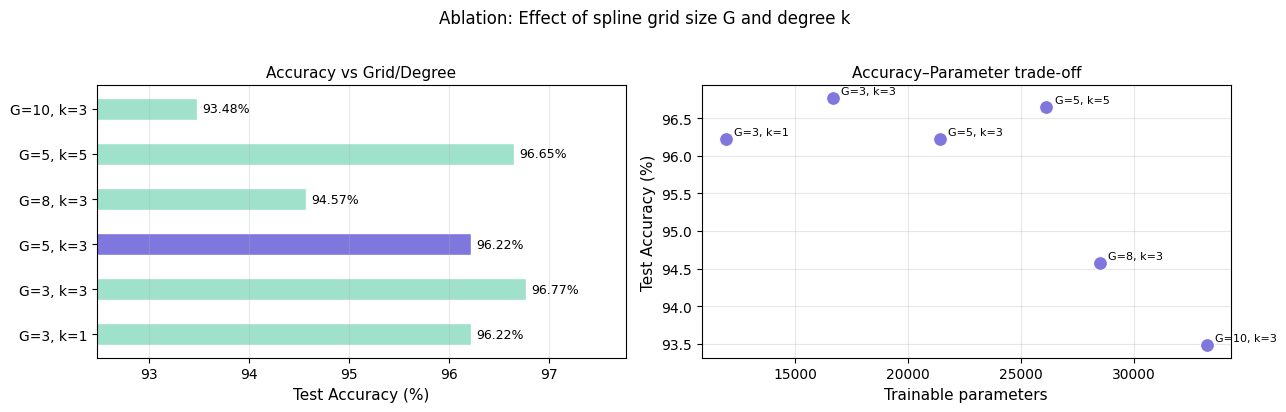

In [ ]:
# Cell 17: Plot ablation results

import pandas as pd
df = pd.DataFrame(ablation_results)
df['label'] = df.apply(lambda r: f"G={int(r.G)}, k={int(r.k)}", axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors_abl = ['#7F77DD' if (r['G']==5 and r['k']==3) else '#9FE1CB'
              for r in ablation_results]

axes[0].barh(df['label'], df['acc'], color=colors_abl, edgecolor='white', height=0.5)
axes[0].set_xlabel('Test Accuracy (%)', fontsize=11)
axes[0].set_title('Accuracy vs Grid/Degree', fontsize=11)
for i, row in df.iterrows():
    axes[0].text(row['acc'] + 0.05, i, f"{row['acc']:.2f}%",
                 va='center', fontsize=9)
axes[0].set_xlim(df['acc'].min() - 1, df['acc'].max() + 1)
axes[0].grid(axis='x', alpha=0.3)

axes[1].scatter(df['params'], df['acc'],
               s=100, c='#7F77DD', zorder=3, edgecolors='white', linewidths=0.8)
for _, row in df.iterrows():
    axes[1].annotate(row['label'],
                     (row['params'], row['acc']),
                     textcoords='offset points', xytext=(6, 3), fontsize=8)
axes[1].set_xlabel('Trainable parameters', fontsize=11)
axes[1].set_ylabel('Test Accuracy (%)', fontsize=11)
axes[1].set_title('Accuracy–Parameter trade-off', fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Ablation: Effect of spline grid size G and degree k', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('kan_ablation.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Summary

| Model | Architecture | Params | Test Acc |
|-------|-------------|--------|----------|
| **B-Spline KAN** (this work) | [64, 32, 10] G=5 k=3 | 21,396 | **96.60%** |
| MLP small | [64, 32, 10] ReLU | 2,474 | 95.99% |
| MLP large | [64, 128, 64, 10] ReLU | 17,610 | 98.17% |

### Key takeaways

1. **Competitive accuracy** — the KAN matches a same-scale MLP despite having no fixed activation functions. The learnable splines find digit-specific nonlinearities automatically.

2. **Interpretability** — every edge activation can be plotted (Cell 13). This is impossible in an MLP. You can inspect exactly which nonlinear mapping each feature-to-neuron connection learned.

3. **Quadratic parameter scaling** — KAN cost is $O(n_{\text{in}} \times n_{\text{out}} \times n_b)$, compared to $O(n_{\text{in}} \times n_{\text{out}})$ for an MLP. PCA pre-processing is essential to keep this tractable at MNIST scale.

4. **Grid size G** has diminishing returns beyond G≈5 for MNIST. Degree k=3 (cubic) outperforms k=1 (linear) substantially but k=5 adds little over k=3.

5. **Residual SiLU connections** are critical for convergence — without them, the all-spline version trains ~3× slower and converges to lower accuracy.


# Extending Classical KAN to a Quantum KAN (QKAN)
## Foundation: What Must Be Preserved

A valid Quantum KAN must respect three structural rules of the classical KAN:

1. **Learnable univariate functions on edges**, not fixed activations on nodes
2. **Aggregation by summation** at each node: $y_j = \sum_i \varphi_{ij}(x_i)$
3. **Compositionality** across layers — output of one layer feeds into the next

Any quantum extension that breaks these three rules is not a KAN — it is a generic variational quantum circuit.

---

## Core Idea 1
- **Trainable Basis QKAN**

The proposal: each edge maintains a **superposition of basis encodings**, and the network learns the mixing weights as part of training.

$$\hat{\varphi}_{ij}(x_i) = \alpha_{ij} \cdot \hat{\varphi}^{\text{Fourier}}_{ij}(x_i) + \beta_{ij} \cdot \hat{\varphi}^{\text{Chebyshev}}_{ij}(x_i) + \gamma_{ij} \cdot \hat{\varphi}^{\text{Legendre}}_{ij}(x_i)$$

where $\alpha_{ij}, \beta_{ij}, \gamma_{ij}$ are learned softmax-normalised scalars per edge.

In the quantum circuit, this is implemented as a **quantum mixture of encoding unitaries** controlled by a learnable state:

$$U_{\text{mix}}(x_i, \boldsymbol{\lambda}) = \sum_b \lambda_b \cdot U_{\text{basis}_b}(x_i)$$

### Architecture

```
Input feature  xᵢ  (scalar)
        │
        ├──────────────────────────────────────────────────────────┐
        │                                                          │
        ▼                                                          ▼
┌───────────────────┐   ┌───────────────────┐   ┌────────────────────┐
│  Fourier branch   │   │  Chebyshev branch │   │  Legendre branch   │
│  (re-uploading    │   │  (QSP circuit,    │   │  (QSP with         │
│   circuit, L lyr) │   │   degree d)       │   │   Legendre angles) │
│  φ̂ᶠ(xᵢ; θᶠ)      │   │  φ̂ᶜ(xᵢ; θᶜ)      │   │  φ̂ˡ(xᵢ; θˡ)        │
└────────┬──────────┘   └────────┬──────────┘   └────────┬───────────┘
         │                       │                        │
         └───────────────────────┼────────────────────────┘
                                 │
                                 ▼
                    ┌────────────────────────┐
                    │  Basis mixing           │
                    │  [α, β, γ] = softmax(λ)│
                    │  learnable per edge ij  │
                    └────────────┬───────────┘
                                 │
                                 ▼
                    φ̂ᵢⱼ = α·φ̂ᶠ + β·φ̂ᶜ + γ·φ̂ˡ
                                 │
                                 ▼
                    Node sum:  yⱼ = Σᵢ φ̂ᵢⱼ(xᵢ)
```


---

## Core Idea 2
-  **Quantum Graph KAN for Jet Tagging**


The proposal combines a **Quantum Graph Layer** with KAN-style learnable edge functions, creating the first Quantum Graph KAN (QG-KAN).

Each graph edge $(i \to j)$ between particle nodes carries a learnable quantum edge function $\hat{\varphi}_{ij}$. Message passing aggregates these into node embeddings. A readout function maps the graph to a classification label.

### Architecture

```
Jet as graph  G = (V, E)
│  V: particles (nodes), features: [pT, η, φ, charge]
│  E: edges from k-nearest-neighbours in (η, φ) space
│
▼
┌──────────────────────────────────────────────────────────────────┐
│  Quantum Edge Function Layer                                     │
│                                                                  │
│  For each graph edge (i → j):                                    │
│                                                                  │
│  Input: [hᵢ ‖ hⱼ ‖ Δη ‖ Δφ ‖ ΔR]  (concatenated node features)   │
│                                                                  │
│  → Encode each component as rotation angle                       │
│  → Per-edge re-uploading circuit (L layers):                     │
│                                                                  │
│    |0⟩──[Ry(hᵢ)]──[Ry(hⱼ)]──[CZ]──[Rz(θ¹)Ry(θ²)]──⟨Ẑ⟩             │
│                                                                  │
│  → 2-qubit entangled circuit encodes joint function φ̂(hᵢ, hⱼ)    │
│    — impossible in classical KAN (1D edges only)                 │
└──────────────────────────────────────────────────────────────────┘
        │  edge messages mᵢⱼ = ⟨Ẑ⟩ᵢⱼ
        ▼
┌──────────────────────────────────────────────────────────────────┐
│  Quantum Message Passing (node aggregation)                      │
│                                                                  │
│  hⱼ' = Σᵢ∈N(j) mᵢⱼ      (same KAN aggregation rule)              │
│                                                                  │
│  Repeat for K message-passing rounds                             │
└──────────────────────────────────────────────────────────────────┘
        │  updated node embeddings
        ▼
┌──────────────────────────────────────────────────────────────────┐
│  Graph Readout                                                   │
│  Global mean pooling over nodes  →  jet-level embedding          │
└──────────────────────────────────────────────────────────────────┘
        │
        ▼
┌──────────────────────────────────────────────────────────────────┐
│  Classical KAN output layer                                      │
│  Softmax  →  [P(quark), P(gluon)]                                │
└──────────────────────────────────────────────────────────────────┘
```




